## Семинар 5: cемантическая сегментация

На этом семинанре мы рассмотрим задачу **коррекции эффектов оптической близости** (OPC, optical proximity correction) в фотолитографии.


Традиционные инструменты **OPC** работают по итерационному алгоритму, требующему многратного повторения операций моделирования и смещения фрагментов топологии. Один из возможных подходов по ускорению этого процесса - применить нейросеть, которая по изображению **исходного дизайна** будет генерировать нам соответствующее изобржение **коррекции**. В режиме инференса такая модель будет давать предсказания за 1 итерацию на GPU вместо 10-15 как это делалось ранее с использованием CPU.

Для решения этой задачи мы можем использовать модели для задачи семантической сегментации. Только в отличие от классической постановки задачи (где по исходному изображению мы должны научить модель предсказывать маску объекта) мы будем просто генерировать масочную коррекцию. И в первом, и во втором случае модель должна будет предсказывать метку класса для каждого пикселя изображения - **"объект"** или **"фон"**.

## Импорт и загрузка библиотек

In [ ]:
!pip install wandb

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import torch
import os

import cv2
import wandb
import torch
import random
import numpy as np
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_sched
import logging
import time
import sys
import os

## Загрузка данных

In [ ]:
!pip install -q gdown

In [ ]:
#https://drive.google.com/file/d/1RtrNpzm5ZgkzwZCgPZoF9bTGjrVdrP68/view?usp=sharing
FILE_ID="1RtrNpzm5ZgkzwZCgPZoF9bTGjrVdrP68"
FILENAME="archive.zip"

!gdown --fuzzy https://drive.google.com/file/d/1RtrNpzm5ZgkzwZCgPZoF9bTGjrVdrP68/view?usp=sharing  -O ${FILENAME}
!unzip -q ${FILENAME}

Downloading...
From (original): https://drive.google.com/uc?id=1RtrNpzm5ZgkzwZCgPZoF9bTGjrVdrP68
From (redirected): https://drive.google.com/uc?id=1RtrNpzm5ZgkzwZCgPZoF9bTGjrVdrP68&confirm=t&uuid=580e75ec-44c0-4824-bcc1-594a780b55ed
To: /content/.zip
100% 157M/157M [00:02<00:00, 66.3MB/s]


## Создадим собственные загрузчики данных

Для этой цели заведём отдельные классы `OPCDataset` и `TestDataset`, в которых будут реализованы методы `len` и `getitem`.

* `len` - должен возвращать длину соответствующего контейнера. В нашем случае длину списка, содержащего пути до изображений
* `getitem` - по индексу должен возвращать конкретный объект из выборки. В нашем случае, получив на вход индекс, мы должны прочитать изображение, применить к нему дополнительные преобразования, и вернуть тензор.


Замечание: для удобства создадим отдельные классы под задачи обучения (OPCDataset) и инференса (TestDataset).

In [ ]:
class OPCDataset(Dataset):
    def __init__(self, image_dir, target_dir, transform=None):
        self.image_dir = image_dir
        self.target_dir = target_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        target_path = os.path.join(self.target_dir, self.images[index])

        image = Image.open(img_path).convert("RGB")
        target = Image.open(target_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
            target = self.transform(target)

        return image, target

class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path

class BinarizeTransform:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def __call__(self, tensor):
        # Assuming the input tensor is of shape (1, 1, 1024, 1024)
        # Convert the tensor to a NumPy array
        image_array = tensor.squeeze().numpy()  # Shape will be (1024, 1024)

        # Binarize the image
        binarized_image = (image_array > self.threshold).astype(np.float32)  # Binary (0 or 1)

        # Convert back to tensor and maintain shape (1, 1, 1024, 1024)
        return torch.from_numpy(binarized_image).unsqueeze(0)  # Shape will be (1, 1, 1024, 1024)

def calculate_mean_std(data_loader):
  total_pixels = 0.0
  total_sum = 0.0
  total_sum_squared = 0.0

  for images, _ in tqdm(data_loader):
      # Assuming the shape of images: (batch_size, 1, H, W)
      total_pixels += images.numel()
      total_sum += images.sum().item()
      total_sum_squared += (images ** 2).sum().item()
  # Compute mean and standard deviation
  mean = total_sum / total_pixels
  std = (total_sum_squared / total_pixels - mean ** 2) ** 0.5

  return round(mean, 5), round(std, 5)

def apply_transform(binarize_flag = False, normalize_flag = False, mean=0, std=0):

  if ((not binarize_flag) and (not normalize_flag)):
      TRANSFORM = transforms.Compose([
          transforms.Resize((1024, 1024)),
          transforms.ToTensor(),
          transforms.Grayscale()])

  elif ((binarize_flag) and (not normalize_flag)):
      TRANSFORM = transforms.Compose([
          transforms.Resize((1024, 1024)),
          transforms.ToTensor(),
          transforms.Grayscale(),
          BinarizeTransform(threshold=0.5)])

  elif ((not binarize_flag) and (normalize_flag)):
      TRANSFORM = transforms.Compose([
          transforms.Resize((1024, 1024)),
          transforms.ToTensor(),
          transforms.Grayscale(),
          transforms.Normalize(mean=[mean], std=[std])])


  return TRANSFORM

Зададим основные параметры для нашего проекта:

In [ ]:
DATASET_PATH = "gds_dataset" # путь до датасета
BATCH_SIZE = 3 # размер батча
LOG_WANDB = False # логирование результатов обучения на платформе weights and biases
EPOCHS = 1 # число эпох
NUM_WORKERS = 2 # число воркеров - параллельная подгрузка данных на диске
LEARNING_RATE = 2e-4
CHECKPOINT_DIR = "checkpoints" # директория, куда будут сохраняться веса, генерируемые картинки в процессе обучения и графики
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:

TRAIN_DATASET = OPCDataset(os.path.join(DATASET_PATH, 'origin/train_origin'),
                            os.path.join(DATASET_PATH, 'correction/train_correction'), transform = apply_transform())
VALID_DATASET = OPCDataset(os.path.join(DATASET_PATH, 'origin/valid_origin'),
                            os.path.join(DATASET_PATH, 'correction/valid_correction'), transform = apply_transform())
TEST_DATASET = OPCDataset(os.path.join(DATASET_PATH, 'origin/test_origin'),
                          os.path.join(DATASET_PATH, 'correction/test_correction'), transform = apply_transform(binarize_flag = True))

TRAIN_LOADER = DataLoader(TRAIN_DATASET, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS)
VALID_LOADER = DataLoader(VALID_DATASET, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS)
TEST_LOADER = DataLoader(TEST_DATASET, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS)

print(f'Number of images in train subset:{len(TRAIN_DATASET)}')
print(f'Number of images in valid subset:{len(VALID_DATASET)}\n')

image, target = next(iter(TRAIN_LOADER))
print(f'Image shape: {image.shape}')
print(f'Target shape: {target.shape}')
print(f'Image shape after removing batch dimension: {image[0,0].shape}')

Number of images in train subset:14398
Number of images in valid subset:1615

Image shape: torch.Size([3, 1, 1024, 1024])
Target shape: torch.Size([3, 1, 1024, 1024])
Image shape after removing batch dimension: torch.Size([1024, 1024])


## Визуализация

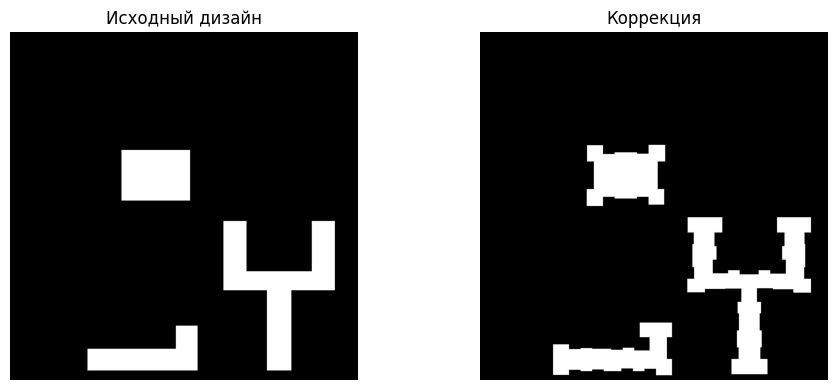

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image[0,0].numpy(), cmap="gray")
axes[0].set_title("Исходный дизайн")
axes[0].axis("off")

axes[1].imshow(target[0,0].numpy(), cmap="gray")
axes[1].set_title("Коррекция")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Модель

In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class conv_block(nn.Module):
    """
    Convolution Block
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, leaky=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True) if not leaky else nn.LeakyReLU(inplace=True))

    def forward(self, x):
        x = self.conv(x)
        return x


class deconv_block(nn.Module):
    """
    Deconvolution Block
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, output_padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, bias=True, output_padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True))

    def forward(self, x):
        x = self.conv(x)
        return x


class Generator(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        n1 = 32
        filters = [n1 * 2, n1 * 4, n1 * 8, n1 * 16, n1 * 32] #[64, 128, 256, 512, 1024]

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv_head = conv_block(in_ch, n1, kernel_size=7, stride=1, padding=3)

        self.conv0 = conv_block(n1, filters[0], stride=2)         #conv_block(32, 64, stride)
        self.conv1 = conv_block(filters[0], filters[1], stride=2) #conv_block(64,128)
        self.conv2 = conv_block(filters[1], filters[2], stride=2) #conv_block(128, 256)
        self.conv3 = conv_block(filters[2], filters[3], stride=2) #conv_block(256, 512)
        self.conv4 = conv_block(filters[3], filters[4], stride=2) #conv_block(512, 1024)

        self.res0 = conv_block(filters[4], filters[4], stride=1) #conv_block()
        self.res1 = conv_block(filters[4], filters[4], stride=1)
        self.res2 = conv_block(filters[4], filters[4], stride=1)
        self.res3 = conv_block(filters[4], filters[4], stride=1)
        self.res4 = conv_block(filters[4], filters[4], stride=1)
        self.res5 = conv_block(filters[4], filters[4], stride=1)
        self.res6 = conv_block(filters[4], filters[4], stride=1)
        self.res7 = conv_block(filters[4], filters[4], stride=1)
        self.res8 = conv_block(filters[4], filters[4], stride=1)

        self.deconv0 = deconv_block(filters[0], n1, stride=2)
        self.deconv1 = deconv_block(filters[1], filters[0], stride=2)
        self.deconv2 = deconv_block(filters[2], filters[1], stride=2)
        self.deconv3 = deconv_block(filters[3], filters[2], stride=2)
        self.deconv4 = deconv_block(filters[4], filters[3], stride=2)

        self.conv_tail = nn.Conv2d(n1, out_ch, kernel_size=7, stride=1, padding=3)


    def forward(self, x):
        x_head = self.conv_head(x)

        x0_0 = self.conv0(x_head)
        x1_0 = self.conv1(x0_0)
        x2_0 = self.conv2(x1_0)
        x3_0 = self.conv3(x2_0)
        x4_0 = self.conv4(x3_0)

        xres = self.res0(x4_0)
        xres = self.res1(xres)
        xres = self.res2(xres)
        xres = self.res3(xres)
        xres = self.res4(xres)
        xres = self.res5(xres)
        xres = self.res6(xres)
        xres = self.res7(xres)
        xres = self.res8(xres)

        x4_1 = self.deconv4(xres)
        x3_1 = self.deconv3(x4_1)
        x2_1 = self.deconv2(x3_1)
        x1_1 = self.deconv1(x2_1)
        x0_1 = self.deconv0(x1_1)

        output = self.conv_tail(x0_1)
        return output

# Убедимся, что модель принимает на вход картинки корректного размера
input_tensor = torch.randn(1, 1, 1024, 1024)

# Создаём модель
generator_model = Generator()

# Выполним предсказания
output = generator_model(input_tensor)

# Проверим форму тензора
print(f"Output shape: {output.shape}")  # Должно быть torch.Size([1, 1, 1024, 1024])
print(f'Model: {generator_model}')

Output shape: torch.Size([1, 1, 1024, 1024])
Model: Generator(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Up): Upsample(scale_factor=2.0, mode='bilinear')
  (conv_head): conv_block(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv0): conv_block(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv1): conv_block(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): conv_block(
    (co

## Подготовка к обучению

Напишем функции для обучения, валидации, сохранения изображений и логирования:

In [ ]:
def set_random_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  np.random.seed(seed)
  random.seed(seed)

set_random_seed(42)

def save_generated_image(output, epoch, step, checkpoint_dir="checkpoints", image_type='true_correction'):
  """
  Функция для сохранения изображений в процессе обучения
  На вход передаётся батч предсказаний модели. Сохраняется только первая катинка из батча
  """
  single_image = output[0].squeeze(dim = 0)
  single_image[single_image > 0.5] = 1.0
  single_image[single_image <= 0.5] = 0.0

  img_save_path = os.path.join(checkpoint_dir, f"{image_type}_epoch{epoch}_step{step}.png")
  cv2.imwrite(f"{img_save_path}", (single_image * 255).detach().cpu().numpy())
  print(f"Saved generated image at {img_save_path}")
  logging.info(f"Saved generated image at {img_save_path}")

def save_inference_image(output_batch, checkpoint_dir="checkpoints", image_type='true_correction'):
  """
  Функция для сохранения изображений в процессе обучения
  На вход передаётся батч предсказаний модели. Сохраняются все изображения из батча
  """

    for i,output in enumerate(output_batch):
        single_image = output.squeeze(dim=0)
        single_image[single_image > 0.5] = 1.0
        single_image[single_image <= 0.5] = 0.0

        single_image_path = image_type[i].split('/')[-1][:-4]
        img_save_path = os.path.join(checkpoint_dir, f"{single_image_path}.jpg")
        cv2.imwrite(f"{img_save_path}", (single_image*255).detach().cpu().numpy())
        print(f"Saved generated image at {img_save_path}")

def setup_logging(exp_folder):
  """
  Логирование в текстовый файл
  """


  log_file_path = os.path.join(exp_folder, 'training_log.txt')
  logging.basicConfig(filename = log_file_path,
                      level = logging.INFO,
                      datefmt = '%d/%m/%Y %H:%M')
def next_exp_folder(checkpoints_dir):
  if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)
  dir_list = os.listdir(checkpoints_dir)
  give_numb = lambda x: int(x.split('_')[-1])
  dir_numbers = [give_numb(name) for name in dir_list if not name.endswith('.gitkeep')]
  max_number = max(dir_numbers)
  new_exp_folder = os.path.join(checkpoints_dir, f'exp_{max_number + 1}')
  os.makedirs(new_exp_folder)
  return new_exp_folder

def draw_plot(**kwargs):

  """
  Отрисовка графиков
  """


  if len(kwargs) == 7:
    plt.figure(figsize=(8, 6))
    plt.plot(kwargs['first_variable'], linestyle='-', label= kwargs['label'])
    plt.title(kwargs['title'])
    plt.xlabel(kwargs['xlabel'])
    plt.ylabel(kwargs['ylabel'])
    plt.grid()
    plt.legend()
    plt.savefig(os.path.join(kwargs['checkpoint_dir'], kwargs['save_name']))
    plt.close()

  # plotting two variables on a plot
  elif len(kwargs) == 9:
    plt.figure(figsize=(8, 6))
    plt.plot(kwargs['first_variable'], linestyle='-', color='r', label= kwargs['first_label'])
    plt.plot(kwargs['second_variable'], linestyle='-', color='b',label = kwargs['second_label'])
    plt.title(kwargs['title'])
    plt.xlabel(kwargs['xlabel'])
    plt.ylabel(kwargs['ylabel'])
    plt.grid()
    plt.legend()
    plt.savefig(os.path.join(kwargs['checkpoint_dir'], kwargs['save_name']))
    plt.close()


## Метрики

Зададим в виде отдельных классов метрики качества, а также функции потерь. В качестве метрик качества будем использовать попиксельную точность и **IoU** (индекс Джаккара). В качестве функций потерь - **L1-разность** и функцию потерь на основе IoU.

In [ ]:
class IouLoss(nn.Module):
  def __init__(self, weight=1.0, eps=1e-6):
    super(IouLoss, self).__init__()
    self.weight = weight
    self.eps = eps
  def forward(self, pred, target):
    intersection = (pred * target).sum(dim=(2, 3))
    union = (pred + target).sum(dim=(2, 3)) - intersection
    iou = (intersection + self.eps) / (union + self.eps)
    return (1 - iou.mean()) * self.weight

class IoU(nn.Module):
  def __init__(self, eps=1e-6):
    super(IoU, self).__init__()
    self.eps = eps

  def forward(self, pred, target):
    intersection = (pred * target).sum(dim=(2, 3))
    union = (pred + target).sum(dim=(2, 3)) - intersection
    iou = (intersection + self.eps) / (union + self.eps)

    return iou.mean()

class PixelAccuracy(nn.Module):
  def __init__(self, eps=1e-6):
    super(PixelAccuracy, self).__init__()
    self.eps = eps

  def forward(self, pred, target):
    pred = pred.clone()
    pred[pred > 0.5] = 1.0
    pred[pred <= 0.5] = 0.0
    correct = (pred == target).float().sum()
    total = torch.numel(target)
    pixel_acc = (correct + self.eps) / (total + self.eps)

    return pixel_acc

In [ ]:
# Define loss functions
iou_loss = IouLoss(weight=1.0)
l1_loss = torch.nn.L1Loss()

# Define metrics
pixel_accuracy = PixelAccuracy()
iou = IoU()

Проверим, насколько адекватно считаются наши метрики:

In [ ]:
output = generator_model(image)
print(f'Output shape: {output.shape}')

iou_loss_value = iou_loss(target, output.sigmoid())
l1_loss_value = l1_loss(target, output.sigmoid())

print(f'IoU loss:{iou_loss_value}')
print(f'L1-loss:{l1_loss_value}')
print(f'IoU loss shape:{iou_loss_value.shape}')
print(f'L1-loss shape:{l1_loss_value.shape}')

Output shape: torch.Size([3, 1, 1024, 1024])
IoU loss:0.9364603161811829
L1-loss:0.46391475200653076
IoU loss shape:torch.Size([])
L1-loss shape:torch.Size([])


In [ ]:
def validate_model(model,
                   val_loader,
                   current_epoch,
                   num_epochs,
                   checkpoint_dir,
                   device = 'cuda'):
  """
  Функции для валидации модели в процессе обучения
  """
  model.eval()
  lossG_l1_epoch = 0
  lossG_iou_epoch = 0
  lossG_epoch = 0
  pixel_acc_epoch = 0
  iou_epoch = 0

  print(f"[Epoch {current_epoch}] Validating")
  logging.info(f"[Epoch {current_epoch}] Validating")

  with torch.no_grad():
    for idx, (image, target) in enumerate(val_loader):
      image, target = image.to(device), target.to(device)

      params = model(image)
      mask = torch.sigmoid(params)
      # считаем лосс в процессе фазы валидации
      lossG_l1_iter = l1_loss(mask, target)
      lossG_iou_iter = iou_loss(mask, target)
      lossG_iter = lossG_l1_iter + lossG_iou_iter

      # считаем точность в процессе валидации
      pixel_acc_iter = pixel_accuracy(mask, target)
      iou_iter = iou(mask, target)

      if idx % 10 == 0:
        log_info_iter = {
          'val/lossG_l1/iter': lossG_l1_iter.item(),
          'val/lossG_iou/iter': lossG_iou_iter.item(),
          'val/lossG/iter': lossG_iter.item(),
          'val/pixel_acc/iter': pixel_acc_iter.item(),
          'val/iou/iter': iou_iter.item()
        }

        log_message_iter = (f"Epoch [{current_epoch}/{num_epochs}], "
                       f"Step [{idx}/{len(val_loader)}], "
                       f"L1 Loss: {log_info_iter['val/lossG_l1/iter']:.4f}, "
                       f"IoU Loss: {log_info_iter['val/lossG_iou/iter']:.4f}, "
                       f"Total Loss: {log_info_iter['val/lossG/iter']:.4f}, "
                       f"Pixel Accuracy: {log_info_iter['val/pixel_acc/iter']:.4f}, "
                       f"IoU: {log_info_iter['val/iou/iter']:.4f}")

        # выводим информацию по лоссам и качеству на текущей итерации и логируем результат в текстовый файл
        print(log_message_iter)
        logging.info(log_message_iter)

        if LOG_WANDB:
          wandb.log(log_info_iter)

      # сохраняем картинку каждую 200 итерацию
      if idx % 200 == 0:
        save_generated_image(mask, current_epoch, idx, checkpoint_dir = checkpoint_dir, image_type = 'generated_correction_val')

      lossG_l1_epoch += lossG_l1_iter.item()
      lossG_iou_epoch += lossG_iou_iter.item()
      lossG_epoch += lossG_iter.item()
      pixel_acc_epoch += pixel_acc_iter.item()
      iou_epoch += iou_iter.item()

    log_info_epoch = {
      'val/lossG_l1/epoch': lossG_l1_epoch / len(val_loader),
      'val/lossG_iou/epoch': lossG_iou_epoch / len(val_loader),
      'val/lossG/epoch': lossG_epoch / len(val_loader),
      'val/pixel_acc/epoch': pixel_acc_epoch / len(val_loader),
      'val/iou/epoch': iou_epoch / len(val_loader)
    }

    log_message_epoch = (f"Losses per epoch [{current_epoch}/{num_epochs}], "
                        f"L1 Loss: {log_info_epoch['val/lossG_l1/epoch']:.4f}, "
                        f"IoU Loss: {log_info_epoch['val/lossG_iou/epoch']:.4f}, "
                        f"Total Loss: {log_info_epoch['val/lossG/epoch']:.4f}, "
                        f"Pixel Accuracy: {log_info_epoch['val/pixel_acc/epoch']:.4f}, "
                        f"IoU: {log_info_epoch['val/iou/epoch']:.4f}")

    # выводим информацию по лоссам и качеству по всей эпохе и логируем результат в текстовый файл
    print(log_message_epoch)
    logging.info(log_message_epoch)

    if LOG_WANDB:
      wandb.log(log_info_epoch)

  # возвращаем средние значения лосса, pixel accuracy, iou по всей эпохе
  return log_info_epoch['val/lossG/epoch'], log_info_epoch['val/pixel_acc/epoch'], log_info_epoch['val/iou/epoch']

In [ ]:
def evaluate_model(model,
                   loader,
                   device='cuda',
                   log = False):
  """
  Функция для оценки качества модели после обучения
  """
  model.eval()

  pixel_acc_epoch = 0
  iou_epoch = 0

  with torch.no_grad():
    for idx, (image, target) in tqdm(enumerate(loader)):
      image, target = image.to(device), target.to(device)
      params = model(image)
      mask = torch.sigmoid(params)

      # подсчёт метрик
      pixel_acc_iter = pixel_accuracy(mask, target)
      iou_iter = iou(mask, target)

      pixel_acc_epoch += pixel_acc_iter.item()
      iou_epoch += iou_iter.item()

    log_info = {
      'pixel_acc': pixel_acc_epoch,
      'iou': iou_epoch,
      'len_loader': len(loader)
    }

    # выводим информацию и логируем результат в текстовый файл
  print(f"Pixel Accuracy: {log_info['pixel_acc'] / log_info['len_loader'] :.4f}, ")
  print(f"IoU: {log_info['iou'] / log_info['len_loader'] :.4f}")

  if log:
    logging.info(f"Pixel Accuracy: {log_info['pixel_acc'] / log_info['len_loader'] :.4f}, ")
    logging.info(f"IoU: {log_info['iou'] / log_info['len_loader'] :.4f}")

In [ ]:
def train_model(model,
                train_loader,
                val_loader,
                num_epochs,
                lr = 2e-4,
                device = "cuda",
                start_epoch = 0,
                checkpoint_dir = "checkpoints"):

  optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = 1e-5)
  # scheduler = lr_sched.StepLR(optimizer=optimizer, step_size=5, gamma=0.5)
  scheduler = lr_sched.CosineAnnealingLR(optimizer = optimizer, T_max = 30, eta_min = 1e-7)
  print('Starting experiment...')
  logging.info('Starting experiment...')
  lossG_epoch_list_train = []
  lossG_epoch_list_val = []
  lossG_iter_list = []

  pixel_acc_epoch_list_train = []
  pixel_acc_epoch_list_val = []

  iou_epoch_list_train = []
  iou_epoch_list_val = []
  model.to(device)
  torch.autograd.set_detect_anomaly(True)
  for epoch in range(start_epoch, num_epochs):
    lossG_l1_epoch = 0
    lossG_iou_epoch = 0
    lossG_epoch = 0
    pixel_acc_epoch = 0
    iou_epoch = 0

    print(f"[Epoch {epoch}] Training")
    logging.info(f"[Epoch {epoch}] Training")
    model.train()

    progress = tqdm(train_loader)

    for idx, (image, target) in enumerate(progress):
      image, target = image.to(device), target.to(device)
      params = model(image)
      mask = torch.sigmoid(params)

      # подсчёт лосса на текущей итерации
      lossG_l1_iter = l1_loss(mask, target)
      lossG_iou_iter = iou_loss(mask, target)
      lossG_iter = lossG_l1_iter + lossG_iou_iter
      lossG_iter_list.append(lossG_iter.item())

      # подсчёт качества на текущей итерации
      pixel_acc_iter = pixel_accuracy(mask, target)
      iou_iter = iou(mask, target)

      optimizer.zero_grad()
      lossG_iter.backward()
      optimizer.step()

      # логируем результат в текстовый файл на каждой 50 итерации
      if idx % 50 == 0:
        # создадим словарик для удобного хранения результатов
        log_info_iter = {
          'train/lossG_l1/iter': lossG_l1_iter.item(),
          'train/lossG_iou/iter': lossG_iou_iter.item(),
          'train/lossG/iter': lossG_iter.item(),
          'train/pixel_acc/iter': pixel_acc_iter.item(),
          'train/iou/iter': iou_iter.item()
        }

        log_message_iter = (f"Epoch [{epoch}/{num_epochs}], "
                       f"Step [{idx}/{len(train_loader)}], "
                       f"L1 Loss: {log_info_iter['train/lossG_l1/iter']:.4f}, "
                       f"IoU Loss: {log_info_iter['train/lossG_iou/iter']:.4f}, "
                       f"Total Loss: {log_info_iter['train/lossG/iter']:.4f}, "
                       f"Pixel Accuracy: {log_info_iter['train/pixel_acc/iter']:.4f}, "
                       f"IoU: {log_info_iter['train/iou/iter']:.4f} ")

        print(log_message_iter)
        logging.info(log_message_iter)

        if LOG_WANDB:
          wandb.log(log_info_iter)

        # отрисовка графика лосса на каждой итерации
        draw_plot(first_variable = lossG_iter_list, label = 'train_iter_loss',
                  title = 'Iteration loss plot', xlabel = 'Iteration',
                  ylabel = 'Loss', save_name = 'train_iter_loss.jpg',
                  checkpoint_dir = checkpoint_dir)

      # cохраняем генерируемые картинки каждую 200 итерацию
      if idx % 200 == 0:
        save_generated_image(mask, epoch, idx, checkpoint_dir = checkpoint_dir, image_type = 'generated_correction')

      lossG_l1_epoch += lossG_l1_iter.item()
      lossG_iou_epoch += lossG_iou_iter.item()
      lossG_epoch += lossG_iter.item()

      pixel_acc_epoch += pixel_acc_iter.item()
      iou_epoch += iou_iter.item()

      if idx % 500 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, 'last_checkpoint.pth')
        torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"Saved checkpoint at {checkpoint_path}")
        logging.info(f"Saved checkpoint at {checkpoint_path}")


    log_info_epoch = {
      'epoch': epoch,
      'train/lossG_l1/epoch': lossG_l1_epoch / len(train_loader),
      'train/lossG_iou/epoch': lossG_iou_epoch / len(train_loader),
      'train/lossG/epoch': lossG_epoch / len(train_loader),
      'train/pixel_acc/epoch': pixel_acc_epoch / len(train_loader),
      'train/iou/epoch': iou_epoch / len(train_loader)
    }

    log_message_epoch = (f"Losses per epoch [{epoch}/{num_epochs}], "
                        f"L1 Loss: {log_info_epoch['train/lossG_l1/epoch']:.4f}, "
                        f"IoU Loss: {log_info_epoch['train/lossG_iou/epoch']:.4f}, "
                        f"Total Loss: {log_info_epoch['train/lossG/epoch']:.4f}"
                        f"Pixel Accuracy: {log_info_epoch['train/pixel_acc/epoch']:.4f}"
                        f"IoU: {log_info_epoch['train/iou/epoch']:.4f}")

    print(log_message_epoch)
    logging.info(log_message_epoch)

    if LOG_WANDB:
      wandb.log(log_info_epoch)

    # получаем средние значения лосса, pixel accuracy, iou по всей эпохе в процессе обучения
    lossG_epoch_list_train.append(log_info_epoch['train/lossG/epoch'])
    pixel_acc_epoch_list_train.append(log_info_epoch['train/pixel_acc/epoch'])
    iou_epoch_list_train.append(log_info_epoch['train/iou/epoch'])

    # получаем средние значения лосса, pixel accuracy, iou по всей эпохе в процессе валидации
    lossG_epoch_val, pixel_acc_epoch_val, iou_epoch_val = validate_model(model,
                                                                         val_loader,
                                                                         current_epoch = epoch,
                                                                         num_epochs = num_epochs,
                                                                         checkpoint_dir = checkpoint_dir,
                                                                         device = device)
    lossG_epoch_list_val.append(lossG_epoch_val)
    iou_epoch_list_val.append(iou_epoch_val)
    pixel_acc_epoch_list_val.append(pixel_acc_epoch_val)

    # отрисовка графика функции потерь по эпохам для фазы обучения и валидации
    draw_plot(first_variable = lossG_epoch_list_train, second_variable = lossG_epoch_list_val,
              title='Loss plot', xlabel='epoch',
              ylabel='loss', first_label='train_loss', second_label='valid_loss',
              save_name='epoch_loss.jpg', checkpoint_dir = checkpoint_dir)

    # отрисовка графика IoU по эпохам для фазы обучения и валидации
    draw_plot(first_variable = iou_epoch_list_train, second_variable = iou_epoch_list_val,
              title = 'IoU plot', xlabel = 'epoch',
              ylabel = 'iou', first_label = 'train_iou', second_label = 'valid_iou',
              save_name = 'epoch_iou.jpg', checkpoint_dir = checkpoint_dir)

    # отрисовка графика Pixel Accuracy по эпохам для фазы обучения и валидации
    draw_plot(first_variable = pixel_acc_epoch_list_train, second_variable = pixel_acc_epoch_list_val,
              title = 'Pixel Accuracy plot', xlabel = 'epoch',
              ylabel = 'pixel accuracy', first_label = 'train_pixel_acc', second_label = 'valid_pixel_acc',
              save_name = 'epoch_pixel_acc.jpg', checkpoint_dir = checkpoint_dir)

    scheduler.step()

  print('Traning complete')
  logging.info('Traning complete')


if LOG_WANDB:
  wandb.login()
  wandb.init(
    project = "MB-OPC",
    name = "DAMO generator",
    config = {
      "architecture": "DAMO Generator",
      "optimizer": "Adam",
      "optimizer_parameters" : 'learning_rate - 2e-4, weight_decay - 1e-5',
      "scheduler" : "CosineAnnealing",
      "scheduler_parameters" : "T_max - 20, eta_min - 1e-7",
      "learning_rate": LEARNING_RATE,
      "epochs" : EPOCHS,
      "dataset": "1024x1024 grayscale images",
      "description": "pretrained DAMO generator"
    }
  )

## Обучение

In [ ]:
# подсчёт времени обучения
start_train = time.time()
# запускаем процесс обучения модели
train_model(model = generator_model,
            train_loader = TRAIN_LOADER,
            val_loader = VALID_LOADER,
            num_epochs = EPOCHS,
            lr = LEARNING_RATE,
            device = DEVICE,
            start_epoch = 0,
            checkpoint_dir = CHECKPOINT_DIR)
end_train = time.time()
total_time = end_train - start_train
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f'Training took: {int(hours):02}:{int(minutes):02}:{int(seconds):02}')
logging.info(f'Training took: {int(hours):02}:{int(minutes):02}:{int(seconds):02}')

## Валидация

In [ ]:
print(f'Evaluating model on validation set..:')
logging.info(f'Evaluating model on validation set..:')
evaluate_model(model = generator_model,
               loader = VALID_LOADER,
               device = DEVICE,
               log = True)
print(f'Evaluating model on test set..:')
logging.info(f'Evaluating model on test set..:')
evaluate_model(model = generator_model,
               loader = TEST_LOADER,
               device = DEVICE,
               log = True)

Evaluating model on validation set..:


539it [03:50,  2.34it/s]

Pixel Accuracy: 0.8769, 
IoU: 0.8441
Evaluating model on test set..:



49it [00:21,  2.33it/s]

Pixel Accuracy: 0.9826, 
IoU: 0.8434


## Инференс

In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/projects/MB-OPC/cv-opc/models/custom_unet_2.pth"
OUTPUT_DIR = "predictions"
BATCH_SIZE = 2

In [ ]:
class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path


In [ ]:
TRANSFORM = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
    transforms.Grayscale(),
    BinarizeTransform(threshold=0.5)
])

# Dataset paths
TEST_DATASET = TestDataset(os.path.join(DATASET_PATH, "origin/test_origin"),
                           transform = TRANSFORM)
# DataLoader
TEST_LOADER = DataLoader(TEST_DATASET, batch_size = BATCH_SIZE, shuffle=False)

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
generator_model = Generator(in_ch = 1, out_ch = 1)
#generator_model.load_state_dict(torch.load(CHECKPOINT_PATH,map_location=torch.device('cpu')))
generator_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location = DEVICE)["model_state_dict"])
generator_model = generator_model.to(DEVICE)
generator_model.eval()
print('Model initialized:', generator_model)
print(f'Total number of parametres in neural network:{sum(p.numel() for p in generator_model.parameters())}')

Model initialized: Generator(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Up): Upsample(scale_factor=2.0, mode='bilinear')
  (conv_head): conv_block(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv0): conv_block(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv1): conv_block(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): conv_block(
    (conv): Sequential(
      (0): Conv2

In [ ]:
time_list= []

for idx, (batch, batch_path) in enumerate(TEST_LOADER):
    start_time = time.time()
    batch = batch.to(DEVICE)
    if idx == 6:
      break
    with torch.no_grad():
        output_batch = generator_model(batch)
        output_mask = torch.sigmoid(output_batch)
    save_inference_image(output_mask, checkpoint_dir = OUTPUT_DIR, image_type = batch_path)
    end_time = time.time()
    print(f'Performed inference within:{end_time - start_time} seconds')
    time_list.append(end_time - start_time)

time_array = np.array(time_list)
print(f'Mean inference time for a single batch of {BATCH_SIZE} images: {time_array.mean()}')
print(f'Mean inference time for a single image: {time_array.mean() / BATCH_SIZE}')

Saved generated image at predictions/cell4646_centered.jpg
Saved generated image at predictions/cell15754_centered.jpg
Performed inference within:0.3863179683685303 seconds
Saved generated image at predictions/cell817_centered.jpg
Saved generated image at predictions/cell11685_centered.jpg
Performed inference within:0.29303526878356934 seconds
Saved generated image at predictions/cell4810_centered.jpg
Saved generated image at predictions/cell10540_centered.jpg
Performed inference within:0.29494571685791016 seconds
Saved generated image at predictions/cell7799_centered.jpg
Saved generated image at predictions/cell11258_centered.jpg
Performed inference within:0.2954263687133789 seconds
Saved generated image at predictions/cell8985_centered.jpg
Saved generated image at predictions/cell5284_centered.jpg
Performed inference within:0.29451847076416016 seconds
Saved generated image at predictions/cell15268_centered.jpg
Saved generated image at predictions/cell9129_centered.jpg
Performed infer

Отобразим результат:

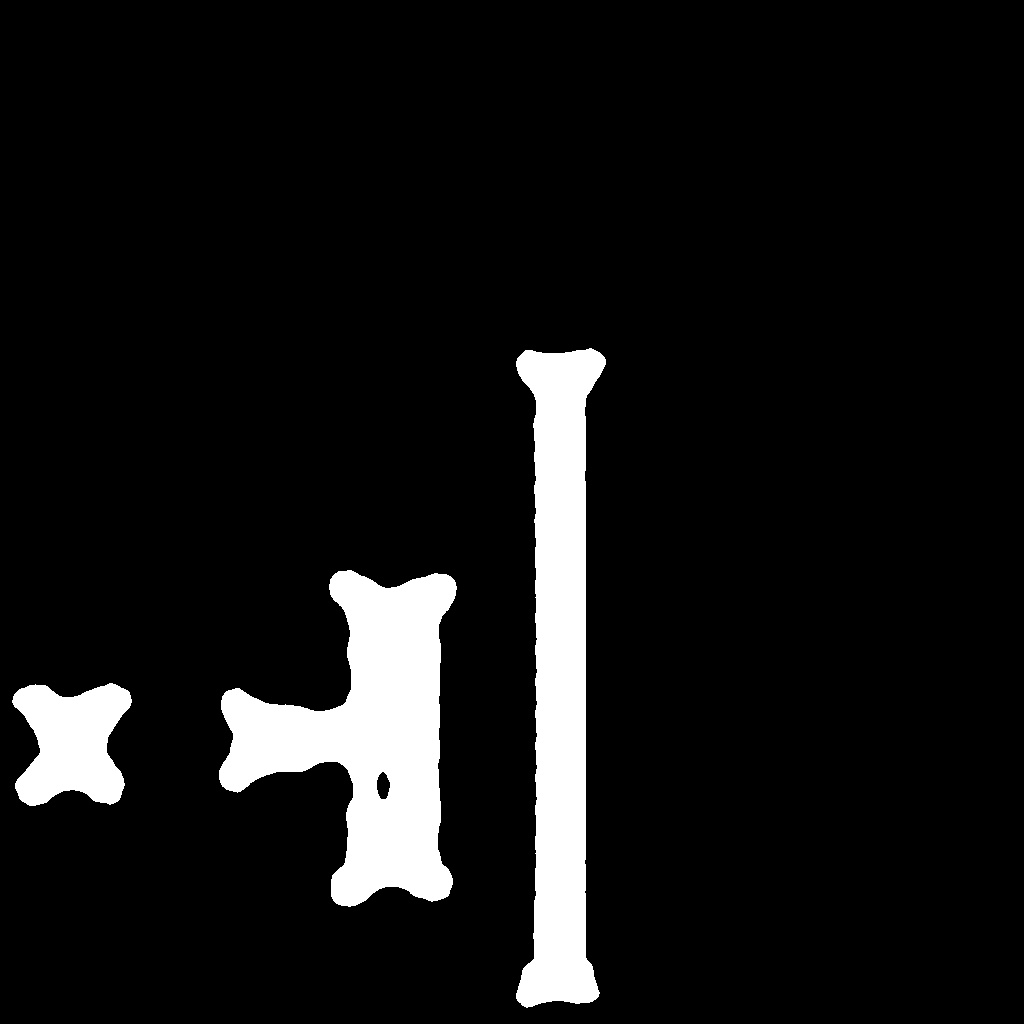

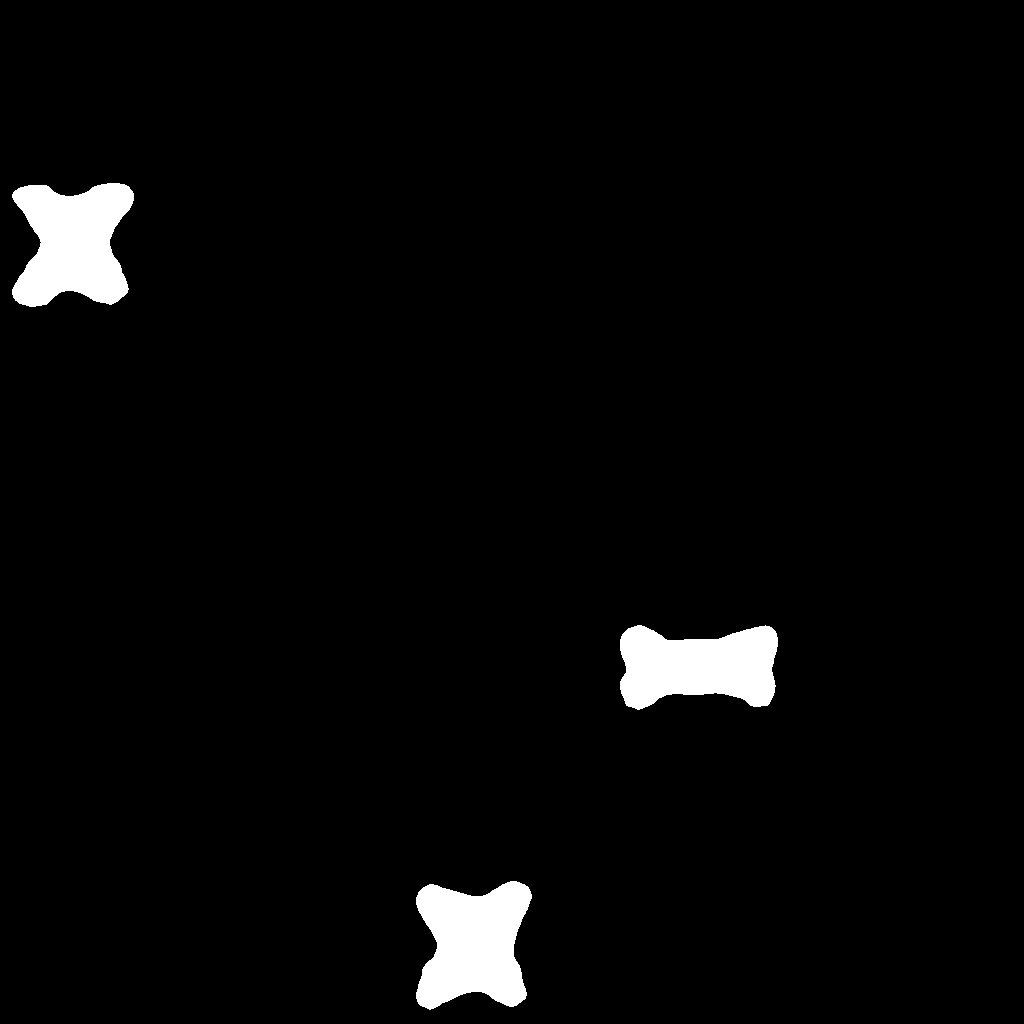

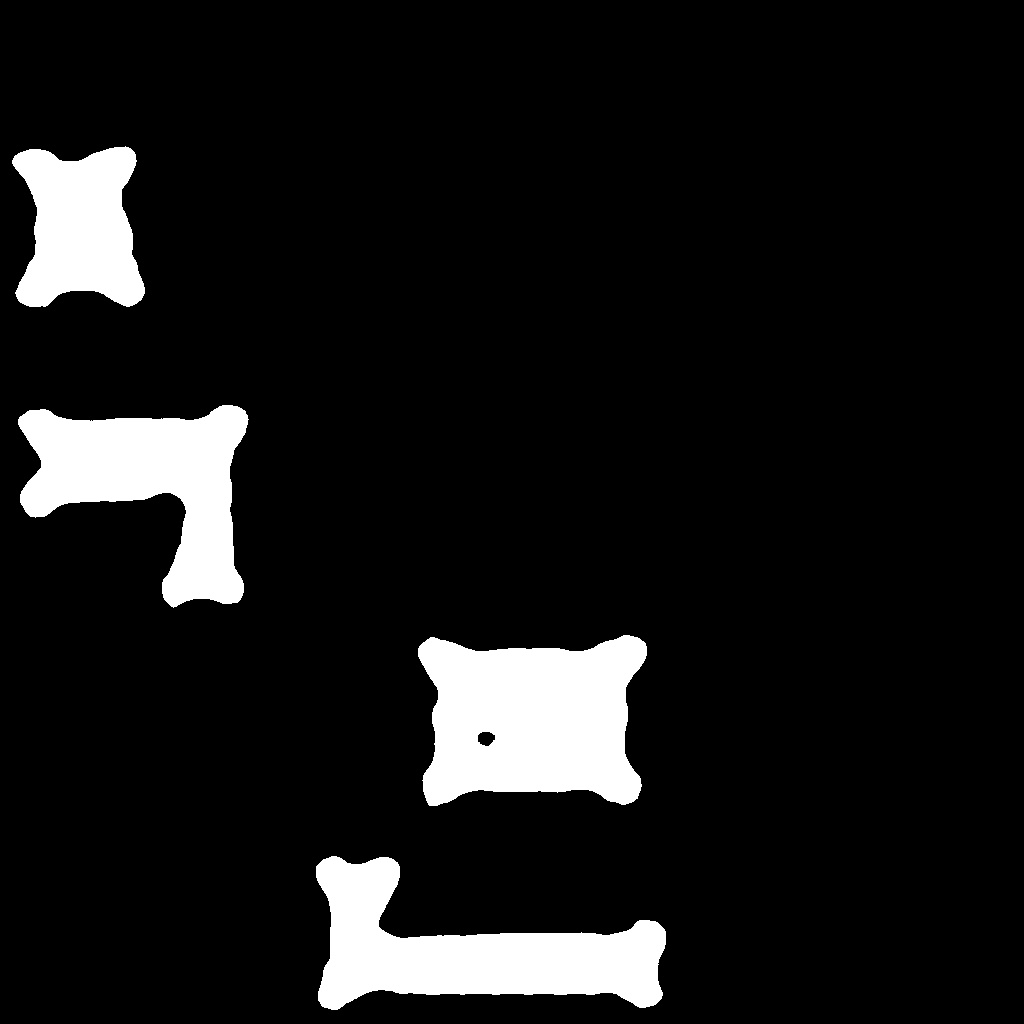

In [ ]:
from IPython.display import Image, display
import glob

i = 0
limit = 3  # max images to print
for imageName in glob.glob("/content/predictions/*.jpg"):  # assuming JPG
    if i < limit:
        display(Image(filename=imageName, width=300, height=300))
        print("\n")
    i = i + 1